# 10-K Coverage & Survivorship Bias Diagnostic

Answers three questions before building any portfolio:

1. **Coverage** — how many companies have a 10-K in our dataset for each year?
2. **Survivorship bias** — are we accidentally using pre-S&P-500-entry filings (forward-looking)?
3. **Portfolio universe** — how many stocks are usable (in index AND have 10-K) each year for long/short?

## 0. Mount Drive & config

In [11]:
import glob
from tqdm.auto import tqdm

pq_files = sorted(glob.glob(f'{DRIVE_FILINGS}/**/*_filings.parquet', recursive=True))
print(f'Parquet files found: {len(pq_files)}')

records = []
for pq in tqdm(pq_files, desc='Loading parquets'):
    try:
        df = pd.read_parquet(pq, columns=['cik', 'year', 'filing_type', 'filing_date'])
        records.append(df)
    except Exception as e:
        print(f'  Skip {pq}: {e}')

filings = pd.concat(records, ignore_index=True)
# Normalise CIK: strip whitespace and leading zeros to match WRDS format
filings['cik']  = filings['cik'].astype(str).str.strip().str.lstrip('0')
filings['year'] = pd.to_numeric(filings['year'], errors='coerce').astype('Int64')
filings = filings.dropna(subset=['year'])
filings = filings[filings['year'].between(YEARS[0], YEARS[-1])]

print(f'\nTotal filing-rows loaded : {len(filings):,}')
print(f'Unique CIKs              : {filings["cik"].nunique():,}')
print(f'Year range               : {filings["year"].min()} – {filings["year"].max()}')
print(f'Sample CIKs from parquet : {filings["cik"].head(5).tolist()}')
filings.head(4)

Parquet files found: 977


Loading parquets:   0%|          | 0/977 [00:00<?, ?it/s]


Total filing-rows loaded : 15,596
Unique CIKs              : 976
Year range               : 2004 – 2025
Sample CIKs from parquet : ['1000180', '1000180', '1000180', '1000180', '1000180']


,cik,year,filing_type,filing_date
0,1000180,2004,10-K,2004-03-12
1,1000180,2005,10-K,2005-03-18
2,1000180,2006,10-K,2006-03-15
3,1000180,2007,10-K,2007-02-28


## 1. Load parquet files → coverage matrix

For each CIK build a set of years for which we have an extracted 10-K.

In [13]:
import wrds

db = wrds.Connection()

membership_query = """
SELECT DISTINCT
    c.cik,
    c.conm,
    m.start,
    m.ending
FROM crsp.msp500list m
JOIN crsp.ccmxpf_linktable l
    ON m.permno = l.lpermno
    AND l.linktype IN ('LU', 'LC')
    AND l.linkprim IN ('P', 'C')
JOIN comp.company c
    ON l.gvkey = c.gvkey
WHERE c.cik IS NOT NULL
  AND m.start <= '2025-12-31'
  AND (m.ending IS NULL OR m.ending >= '2003-01-01')
"""

membership = db.raw_sql(membership_query)

# Normalise CIK: strip whitespace and leading zeros — must match parquet CIK format
membership['cik']    = membership['cik'].astype(str).str.strip().str.lstrip('0')
membership['start']  = pd.to_datetime(membership['start'])
membership['ending'] = pd.to_datetime(membership['ending'])

sp500_spans = membership.copy()
print(f'S&P 500 spans loaded: {len(sp500_spans):,} rows, {sp500_spans["cik"].nunique():,} unique CIKs')
print(f'Sample CIKs from WRDS: {sp500_spans["cik"].head(5).tolist()}')

# Sanity check: how many CIKs overlap with our parquet files?
overlap = set(filings['cik'].unique()) & set(sp500_spans['cik'].unique())
print(f'\nCIK overlap (parquet ∩ WRDS): {len(overlap):,} companies')
if len(overlap) == 0:
    print('⚠ Zero overlap — CIK format still mismatched. Print examples above and compare.')
sp500_spans.head(4)

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
S&P 500 spans loaded: 1,010 rows, 962 unique CIKs
Sample CIKs from WRDS: ['1800', '2135', '2488', '2488', '2969']

CIK overlap (parquet ∩ WRDS): 936 companies


,cik,conm,start,ending
0,1800,ABBOTT LABORATORIES,1957-03-01,2024-12-31
1,2135,AFFILIATED COMPUTER SERVICES,2004-04-02,2010-02-05
2,2488,ADVANCED MICRO DEVICES,1984-06-21,2013-09-20
3,2488,ADVANCED MICRO DEVICES,2017-03-20,2024-12-31


## 2. Load S&P 500 membership from WRDS

We need the **entry** (`start`) and **exit** (`ending`) dates for each company
to know which years a CIK was actually IN the index.

**No look-ahead bias here**: the `in_sp500` flag for year Y uses only membership dates
that were observable at year Y. A company is marked as in-index for year Y if and only
if it was a constituent during that calendar year — using the historical `start` and
`ending` columns from `crsp.msp500list`. We never include a company based on its
*future* index membership.

In [14]:
# Build year-level in_sp500 lookup efficiently
sp500_year_set: dict[str, set[int]] = {}
for _, row in sp500_spans.iterrows():
    cik   = row['cik']
    start = row['start'].year
    end   = row['ending'].year if pd.notna(row['ending']) else YEARS[-1]
    for y in range(max(start, YEARS[0]), min(end, YEARS[-1]) + 1):
        sp500_year_set.setdefault(cik, set()).add(y)

# Build full grid
has_10k_map: dict[str, set[int]] = (
    filings.groupby('cik')['year']
           .apply(lambda s: set(s.dropna().astype(int).tolist()))
           .to_dict()
)

sp_entry: dict[str, int] = (
    sp500_spans.groupby('cik')['start']
               .min().dt.year.to_dict()
)

all_ciks = set(has_10k_map) | set(sp500_year_set)
rows = []
for cik in all_ciks:
    h10k   = has_10k_map.get(cik, set())
    in_sp  = sp500_year_set.get(cik, set())
    entry  = sp_entry.get(cik, None)
    for y in YEARS:
        rows.append({
            'cik':           cik,
            'year':          y,
            'has_10k':       y in h10k,
            'in_sp500':      y in in_sp,
            'sp_entry_year': entry,
        })

grid = pd.DataFrame(rows)
grid['usable']        = grid['has_10k'] & grid['in_sp500']
grid['pre_entry_10k'] = grid['has_10k'] & ~grid['in_sp500'] & (grid['year'] < grid['sp_entry_year'].fillna(9999))

print(f'Grid: {grid.shape}')
print(f'Usable rows : {grid["usable"].sum():,}')
print(f'Pre-entry   : {grid["pre_entry_10k"].sum():,}')
grid[grid['usable']].head(4)

Grid: (21978, 7)
Usable rows : 10,264
Pre-entry   : 2,817


,cik,year,has_10k,in_sp500,sp_entry_year,usable,pre_entry_10k
44,1141982,2004,True,True,1957.0,True,False
45,1141982,2005,True,True,1957.0,True,False
46,1141982,2006,True,True,1957.0,True,False
47,1141982,2007,True,True,1957.0,True,False


## 3. Year-level intersection: in-index × has-10K

For every (CIK, year) combination, flag whether:
- `in_sp500`  — the company was in the S&P 500 at any point during that calendar year
- `has_10k`   — we have an extracted 10-K for that year

In [15]:
# For each CIK, which years were they in the S&P 500?
def membership_years(spans: pd.DataFrame, years: list[int]) -> dict[str, set[int]]:
    result: dict[str, set[int]] = {}
    for _, row in spans.iterrows():
        cik   = row['cik']
        start = row['start'].year
        end   = row['ending'].year if pd.notna(row['ending']) else years[-1]
        for y in range(max(start, years[0]), min(end, years[-1]) + 1):
            result.setdefault(cik, set()).add(y)
    return result

sp500_year_map = membership_years(sp500_spans, YEARS)

# Build full grid
rows = []
all_ciks = set(filings['cik'].unique()) | set(sp500_year_map.keys())
for cik in all_ciks:
    has_10k_years  = set(filings.loc[filings['cik'] == cik, 'year'].tolist())
    in_sp500_years = sp500_year_map.get(cik, set())
    sp_entry_year  = int(sp500_spans.loc[sp500_spans['cik'] == cik, 'start'].dt.year.min()) if cik in sp500_year_map else None
    for y in YEARS:
        rows.append({
            'cik':          cik,
            'year':         y,
            'has_10k':      y in has_10k_years,
            'in_sp500':     y in in_sp500_years,
            'sp_entry_year': sp_entry_year,
        })

grid = pd.DataFrame(rows)
grid['usable']         = grid['has_10k'] & grid['in_sp500']
grid['pre_entry_10k']  = grid['has_10k'] & ~grid['in_sp500'] & (grid['year'] < grid['sp_entry_year'].fillna(9999))

print(f'Grid shape: {grid.shape}')
grid.head(6)

Grid shape: (21978, 7)


,cik,year,has_10k,in_sp500,sp_entry_year,usable,pre_entry_10k
0,716823,2004,True,False,NaN,False,True
1,716823,2005,True,False,NaN,False,True
2,716823,2006,True,False,NaN,False,True
3,716823,2007,True,False,NaN,False,True
4,716823,2008,True,False,NaN,False,True
5,716823,2009,False,False,NaN,False,False


## 4. Coverage per year

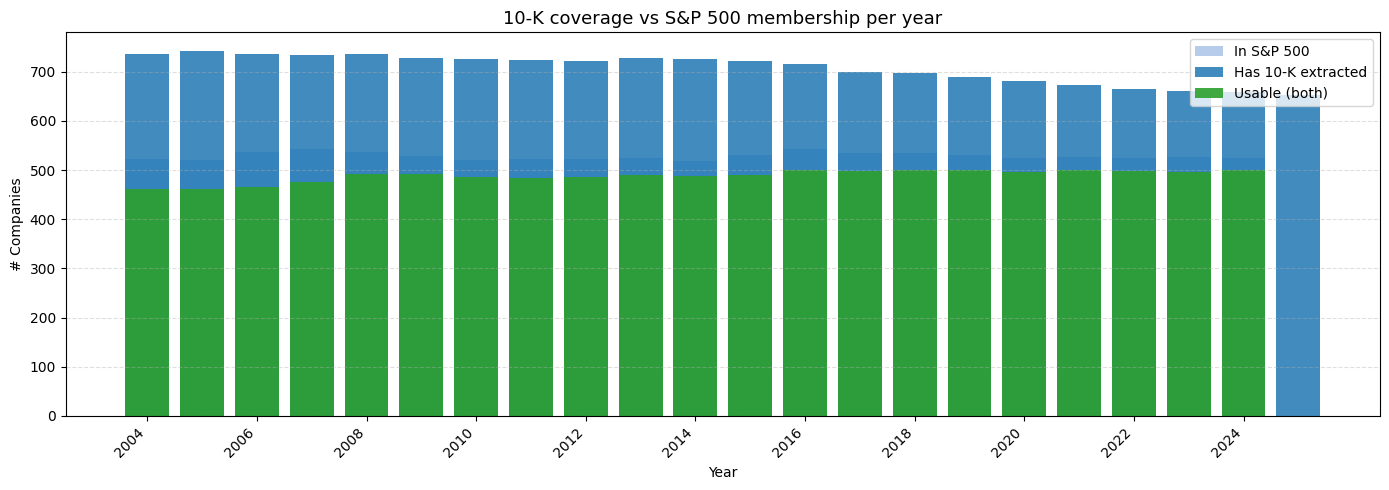

 year  in_sp500  has_10k  usable
 2004       523      737     462
 2005       521      743     462
 2006       536      737     465
 2007       542      735     476
 2008       537      737     491
 2009       529      728     493
 2010       520      726     485
 2011       523      723     484
 2012       523      722     485
 2013       524      727     489
 2014       519      726     487
 2015       531      722     490
 2016       542      715     501
 2017       534      699     499
 2018       534      697     501
 2019       531      690     501
 2020       525      682     497
 2021       527      674     500
 2022       524      665     499
 2023       526      661     497
 2024       525      658     500
 2025         0      652       0


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

annual = grid.groupby('year').agg(
    in_sp500  =('in_sp500',  'sum'),
    has_10k   =('has_10k',   'sum'),
    usable    =('usable',    'sum'),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = annual['year']
ax.bar(x, annual['in_sp500'],  label='In S&P 500',         color='#aec7e8', alpha=0.9)
ax.bar(x, annual['has_10k'],   label='Has 10-K extracted', color='#1f77b4', alpha=0.85)
ax.bar(x, annual['usable'],    label='Usable (both)',       color='#2ca02c', alpha=0.9)

ax.set_title('10-K coverage vs S&P 500 membership per year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('# Companies')
ax.set_xticks(x[::2])
ax.set_xticklabels(x[::2], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FML_project_4/coverage_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(annual.to_string(index=False))

## 5. Survivorship bias analysis

**The risk:** a company joined the S&P 500 in 2015 but we have its 10-K from 2004 onwards.
If we include pre-2015 filings in our panel we are implicitly conditioning on the fact that
the company survived long enough to enter the index — a classic look-ahead bias.

We quantify:
- How many companies have 10-Ks **before** their first S&P 500 entry year?
- How large is the pre-entry window?

Companies with pre-S&P-500-entry 10-Ks : 367 / 999
Average pre-entry window               : 7.8 years
Max pre-entry window                   : 22 years


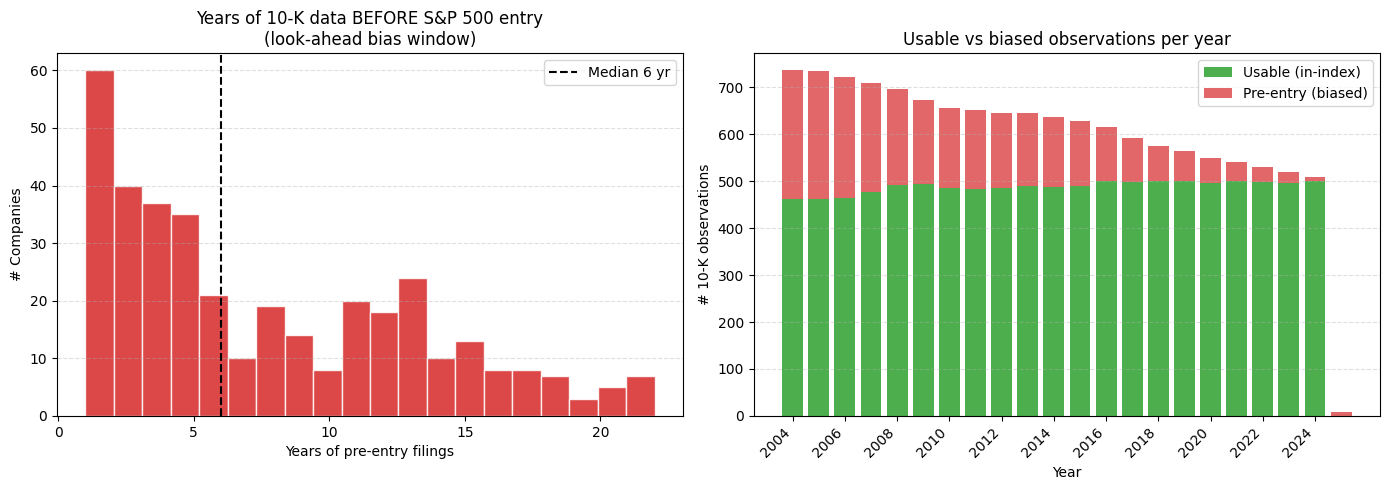

In [17]:
per_cik = grid.groupby('cik').agg(
    earliest_10k     =('year', lambda s: s[grid.loc[s.index, 'has_10k']].min() if grid.loc[s.index, 'has_10k'].any() else pd.NA),
    sp_entry_year    =('sp_entry_year', 'first'),
    pre_entry_10k_yrs=('pre_entry_10k', 'sum'),
    total_10k_yrs    =('has_10k', 'sum'),
).reset_index()

per_cik['gap_years'] = per_cik['sp_entry_year'] - per_cik['earliest_10k']
per_cik['gap_years'] = per_cik['gap_years'].clip(lower=0)

biased = per_cik[per_cik['pre_entry_10k_yrs'] > 0]
print(f'Companies with pre-S&P-500-entry 10-Ks : {len(biased):,} / {per_cik["cik"].nunique():,}')
print(f'Average pre-entry window               : {biased["pre_entry_10k_yrs"].mean():.1f} years')
print(f'Max pre-entry window                   : {biased["pre_entry_10k_yrs"].max():.0f} years')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of pre-entry filing years
axes[0].hist(biased['pre_entry_10k_yrs'], bins=20, color='#d62728', edgecolor='white', alpha=0.85)
axes[0].axvline(biased['pre_entry_10k_yrs'].median(), color='black', linestyle='--',
                label=f'Median {biased["pre_entry_10k_yrs"].median():.0f} yr')
axes[0].set_title('Years of 10-K data BEFORE S&P 500 entry\n(look-ahead bias window)')
axes[0].set_xlabel('Years of pre-entry filings')
axes[0].set_ylabel('# Companies')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Pre-entry 10-Ks per year (how many "biased" observations exist each year)
pre_entry_by_year = grid[grid['pre_entry_10k']].groupby('year')['cik'].count()
pre_entry_by_year = pre_entry_by_year.reindex(YEARS, fill_value=0)
usable_by_year    = grid[grid['usable']].groupby('year')['cik'].count()
usable_by_year    = usable_by_year.reindex(YEARS, fill_value=0)

axes[1].bar(YEARS, usable_by_year,    label='Usable (in-index)',   color='#2ca02c', alpha=0.85)
axes[1].bar(YEARS, pre_entry_by_year, label='Pre-entry (biased)',  color='#d62728', alpha=0.7,
            bottom=usable_by_year)
axes[1].set_title('Usable vs biased observations per year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('# 10-K observations')
axes[1].set_xticks(YEARS[::2])
axes[1].set_xticklabels(YEARS[::2], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FML_project_4/survivorship_bias.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Portfolio universe per year

For a long/short portfolio you need at least ~50 stocks per year to form quintiles.
The table below shows the investable universe **after** restricting to in-index filings only.

**Fix for survivorship bias:** the `nlp_features.ipynb` merge should inner-join on
`(cik, year)` pairs where `in_sp500 == True`. Save `usable_pairs.parquet` here for that join.

In [18]:
print('Portfolio universe (usable = in S&P 500 AND has 10-K)')
print('='*55)
for _, row in annual.iterrows():
    bar = '█' * int(row['usable'] / 5)
    flag = ' ⚠ LOW' if row['usable'] < 50 else ''
    print(f"  {int(row['year'])}: {int(row['usable']):>4} companies  {bar}{flag}")

# Save usable (cik, year) pairs for downstream merge
usable_pairs = grid[grid['usable']][['cik', 'year']].reset_index(drop=True)
usable_pairs.to_parquet('/content/drive/MyDrive/FML_project_4/usable_pairs.parquet', index=False)
print(f'\nSaved usable_pairs.parquet: {len(usable_pairs):,} (cik, year) pairs')
print('Use this to filter nlp_features before any regression or portfolio sort.')

Portfolio universe (usable = in S&P 500 AND has 10-K)
  2004:  462 companies  ████████████████████████████████████████████████████████████████████████████████████████████
  2005:  462 companies  ████████████████████████████████████████████████████████████████████████████████████████████
  2006:  465 companies  █████████████████████████████████████████████████████████████████████████████████████████████
  2007:  476 companies  ███████████████████████████████████████████████████████████████████████████████████████████████
  2008:  491 companies  ██████████████████████████████████████████████████████████████████████████████████████████████████
  2009:  493 companies  ██████████████████████████████████████████████████████████████████████████████████████████████████
  2010:  485 companies  █████████████████████████████████████████████████████████████████████████████████████████████████
  2011:  484 companies  ██████████████████████████████████████████████████████████████████████████████████

## 7. What to do

| Issue | Fix |
|---|---|
| Pre-entry filings (look-ahead bias) | Filter panel to `usable_pairs.parquet` — only keep (cik, year) where company was in S&P 500 that year |
| Companies missing 10-Ks for some years | Use them when available; don't forward-fill |
| Low universe years (< 50 stocks) | Note in paper; avoid portfolio sorts for those years |
| Companies that delisted mid-year | CRSP `ending` date handles this — they're excluded after exit year |

The `usable_pairs.parquet` file is the master filter. In `nlp_features.ipynb`:
```python
usable = pd.read_parquet('usable_pairs.parquet')
panel = nlp_features.merge(usable, on=['cik', 'year'], how='inner')
```